In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 1-ci quyu ucun PBU 
well_name = 'well_1'
file_path = r"C:\Users\Amin\Downloads\data\data\Section 1\well_01_DHP_data..csv"

ts_col = 'timestamp'
pr_col = 'dhp'

# task kriteriyalari
min_rise_psi   = 600   # en az 600 psi artis
min_duration_h = 2     # en az 2 saat davamliliq

# signal processing parameters
median_window = '20min'   # noise temizleme (median filter)
mean_window   = '10min'   # additional smoothing
noise_mult    = 4.0       # decline_tol = noise_mult * approximate noise
min_decline_tol = 15.0    # decline_tol bu deyerin altina dusmesin

# outlier temizleme 
outlier_window     = 5      # nece qonsu noqte ile lokal medyan hesablanacaq
outlier_threshold  = 500    # lokal medyandan bu qeder (psi) uzaqlasan noqteler atilir

# stagnation limit (hereketsizlik limiti)
max_stagnant_hours = 6 #eger 6 saatdan artiq artis olmadan zaman kecerse PBU sifirlanir
min_valid_psi=100
trough_reset_hours=3

In [21]:
def remove_outliers(df, pr_col='pressure', window=outlier_window, threshold_psi=outlier_threshold):
    #sensor glitch-leri temizlenir (sensordaki ani sicramalar)
    local_median = df[pr_col].rolling(window, center=True, min_periods=1).median()
    deviation = (df[pr_col] - local_median).abs()
    mask = deviation > threshold_psi
    n_out = int(mask.sum())
    if n_out:
        df = df.loc[~mask].copy()
    return df


def load_well_data(filepath, ts_col=ts_col, pr_col=pr_col):
    try:
        df = pd.read_csv(filepath, usecols=[ts_col, pr_col], engine='pyarrow')
    except Exception:
        df = pd.read_csv(filepath, usecols=[ts_col, pr_col])

    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')

    #menfi sonsuzluq kimi deyerler varsa, o deyerleri kecir, hesablamaya almir
    n_inf = np.isinf(df[pr_col]).sum()
    if n_inf:
        df.loc[np.isinf(df[pr_col]), pr_col] = np.nan

    #NaN deyerler hesablamadan kenar qalir
    n_nan_pressure = df[pr_col].isna().sum()
    if n_nan_pressure:
        df = df.dropna(subset=[pr_col])

    #100 psi-den asagi tezyiq deyerleri hesablamaya alinmir
    n_floor = int((df[pr_col] < min_valid_psi).sum())
    if n_floor:
        df = df[df[pr_col] >= min_valid_psi]

    df[pr_col] = df[pr_col].astype('float32')

    #timestamp sutununda bezi deyerlerde zamanin yaninda birlesik qalan T herflerini silib, datetime formatina cevirme
    ts_raw = df[ts_col].astype(str).str.strip()
    ts_raw = ts_raw.str.replace(r'(\d)T$', r'\1', regex=True)
    df[ts_col] = pd.to_datetime(ts_raw, format="mixed", errors='coerce')

    #eger yene ayird edile bilmeyen tarix deyerleri qalarsa atilir
    n_bad_ts = df[ts_col].isna().sum()
    if n_bad_ts:
        df = df.dropna(subset=[ts_col])

    df = df.rename(columns={ts_col: 'timestamp', pr_col: 'pressure'})
    df = (df.sort_values('timestamp')
            .drop_duplicates(subset='timestamp')
            .set_index('timestamp'))

    df = remove_outliers(df)
    return df

In [22]:
#raw data haqqinda melumat almaq 
df = load_well_data(file_path)

print(f'rows: {len(df):,}')
print(f'date range: {df.index.min()}  ->  {df.index.max()}')
print(f'pressure range: {df["pressure"].min():.1f} - {df["pressure"].max():.1f} psi')
df.head()

rows: 7,865,032
date range: 2015-03-14 08:16:11.300000+00:00  ->  2023-06-01 03:41:36.210000+00:00
pressure range: 2214.2 - 9240.3 psi


,pressure
timestamp,
2015-03-14 08:16:11.300000+00:00,"4,448.07"
2015-03-14 08:16:11.378000+00:00,"4,448.07"
2015-03-14 09:04:53.200000+00:00,"4,447.92"
2015-03-14 09:04:53.269000+00:00,"4,447.92"
2015-03-14 10:04:45.100000+00:00,"4,447.78"


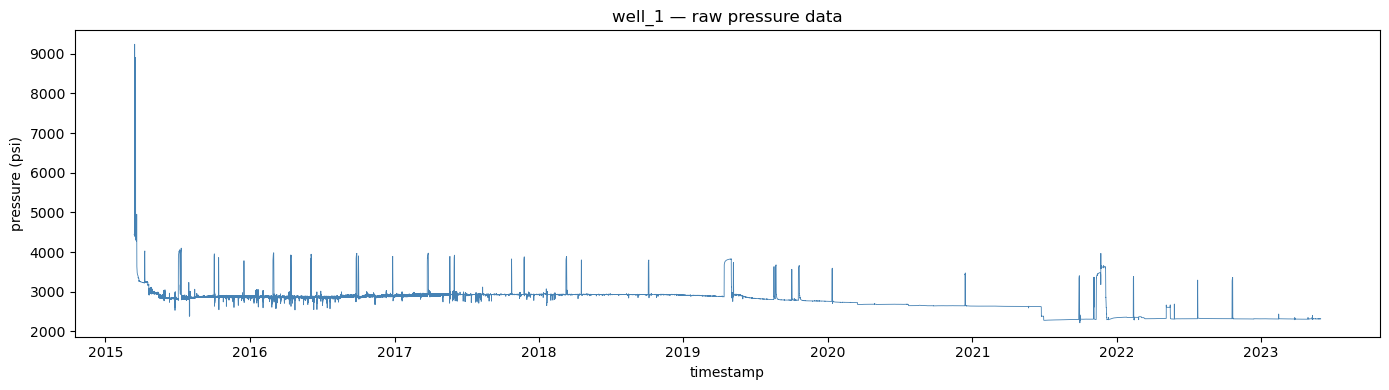

In [23]:
#raw data-ni vizuallasdirma
fig, ax = plt.subplots(figsize=(14, 4))
sample_step = max(1, len(df) // 200_000)
ax.plot(df.index[::sample_step], df['pressure'].values[::sample_step], lw=0.6, color='steelblue')
ax.set_title(f'{well_name} — raw pressure data')
ax.set_xlabel('timestamp')
ax.set_ylabel('pressure (psi)')
plt.tight_layout()
plt.show()

In [24]:
#smoothing/noise cleaning (rolling median + rolling mean)
def smooth_pressure(df, med_win=median_window, mean_win=mean_window):
    s = df['pressure'].rolling(med_win, min_periods=1).median()
    s = s.rolling(mean_win, min_periods=1).mean()
    return s.astype('float32')
smoothed = smooth_pressure(df)

In [25]:
#well_1-e ozel noise level ve düşüş toleransi (decline_tol) hesablama
def estimate_noise_level(smoothed, window='15min', quantile=0.2):
    rolling_std = smoothed.rolling(window, min_periods=5).std()
    noise = rolling_std.quantile(quantile)
    if pd.isna(noise) or noise <= 0:
        noise = smoothed.diff().abs().median() * 3
    return float(noise)

noise = estimate_noise_level(smoothed)
decline_tol = max(min_decline_tol, noise_mult * noise)

In [26]:
def detect_pbus_zigzag(smoothed, decline_tol, min_rise=min_rise_psi,
                        min_duration_hours=min_duration_h,
                        max_stagnant_hours=max_stagnant_hours,
                        trough_reset_hours=trough_reset_hours):
    idx = smoothed.index
    vals = smoothed.values
    n = len(vals)
    max_stagnant = pd.Timedelta(hours=max_stagnant_hours)
    trough_reset = pd.Timedelta(hours=trough_reset_hours)

    results = []
    trough_i, trough_v = 0, vals[0]
    peak_i,   peak_v   = 0, vals[0]
    last_move_i = 0
    state = 'seeking'

    for i in range(1, n):
        v = vals[i]

        if state == 'seeking':
            if v - trough_v >= decline_tol:
                #yukselis basladi
                peak_v, peak_i = v, i
                last_move_i = i
                state = 'rising'
            elif v <= trough_v:
                trough_v, trough_i = v, i
            elif (idx[i] - idx[trough_i]) > trough_reset:
                #uzun muddet yukselis olmadi
                #movcud noqteden yeniden hesablamaga basla
                trough_v, trough_i = v, i

        elif state == 'rising':
            closed = False

            if v > peak_v:
                peak_v, peak_i = v, i
                last_move_i = i

            elif peak_v - v >= decline_tol:
                exact_start, exact_end = idx[trough_i], idx[peak_i]
                duration_h = (exact_end - exact_start).total_seconds() / 3600
                rise = peak_v - trough_v
                if duration_h >= min_duration_hours and rise >= min_rise:
                    results.append({
                        'exact_start': exact_start,
                        'interval_start': exact_start - pd.Timedelta(hours=1.5),
                        'exact_end': exact_end,
                        'interval_end': exact_end + pd.Timedelta(hours=1.5),
                        'duration_hours': round(duration_h, 3),
                        'pressure_change_psi': round(float(rise), 2),
                    })
                trough_v, trough_i = v, i
                state = 'seeking'
                closed = True

            if not closed and (idx[i] - idx[last_move_i]) > max_stagnant:
                exact_start, exact_end = idx[trough_i], idx[peak_i]
                duration_h = (exact_end - exact_start).total_seconds() / 3600
                rise = peak_v - trough_v
                if duration_h >= min_duration_hours and rise >= min_rise:
                    results.append({
                        'exact_start': exact_start,
                        'interval_start': exact_start - pd.Timedelta(hours=1.5),
                        'exact_end': exact_end,
                        'interval_end': exact_end + pd.Timedelta(hours=1.5),
                        'duration_hours': round(duration_h, 3),
                        'pressure_change_psi': round(float(rise), 2),
                    })
                trough_v, trough_i = v, i
                state = 'seeking'

    return pd.DataFrame(results)


result_df = detect_pbus_zigzag(smoothed, decline_tol=decline_tol)
result_df = result_df.sort_values('exact_start').reset_index(drop=True)

print(f'{len(result_df)} PBUs detected for {well_name}.')
result_df

34 PBUs detected for well_1.


,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,2015-03-16 00:33:25.800000+00:00,2015-03-15 23:03:25.800000+00:00,2015-03-16 16:12:06.100000+00:00,2015-03-16 17:42:06.100000+00:00,15.64,"4,194.79"
1,2015-04-09 14:20:47+00:00,2015-04-09 12:50:47+00:00,2015-04-10 09:58:37.603000+00:00,2015-04-10 11:28:37.603000+00:00,19.63,810.86
2,2015-07-04 04:01:19.800000+00:00,2015-07-04 02:31:19.800000+00:00,2015-07-07 23:29:58.900000+00:00,2015-07-08 00:59:58.900000+00:00,91.48,"1,211.06"
3,2015-07-09 18:17:24+00:00,2015-07-09 16:47:24+00:00,2015-07-11 11:15:54.500000+00:00,2015-07-11 12:45:54.500000+00:00,40.98,"1,126.97"
4,2015-10-02 08:11:20+00:00,2015-10-02 06:41:20+00:00,2015-10-03 06:36:55.336000+00:00,2015-10-03 08:06:55.336000+00:00,22.43,"1,084.45"
5,2015-10-13 21:54:19.100000+00:00,2015-10-13 20:24:19.100000+00:00,2015-10-14 02:44:20.400000+00:00,2015-10-14 04:14:20.400000+00:00,4.83,996.85
6,2015-12-16 09:27:29.400000+00:00,2015-12-16 07:57:29.400000+00:00,2015-12-17 04:01:51.300000+00:00,2015-12-17 05:31:51.300000+00:00,18.57,993.63
7,2016-02-28 04:44:51+00:00,2016-02-28 03:14:51+00:00,2016-03-01 09:27:55.350000+00:00,2016-03-01 10:57:55.350000+00:00,52.72,"1,130.16"
8,2016-04-11 01:49:21.804000+00:00,2016-04-11 00:19:21.804000+00:00,2016-04-12 21:36:10.304000+00:00,2016-04-12 23:06:10.304000+00:00,43.78,907.98
9,2016-09-25 12:53:13.700000+00:00,2016-09-25 11:23:13.700000+00:00,2016-09-27 14:23:29.681000+00:00,2016-09-27 15:53:29.681000+00:00,49.50,"1,216.88"


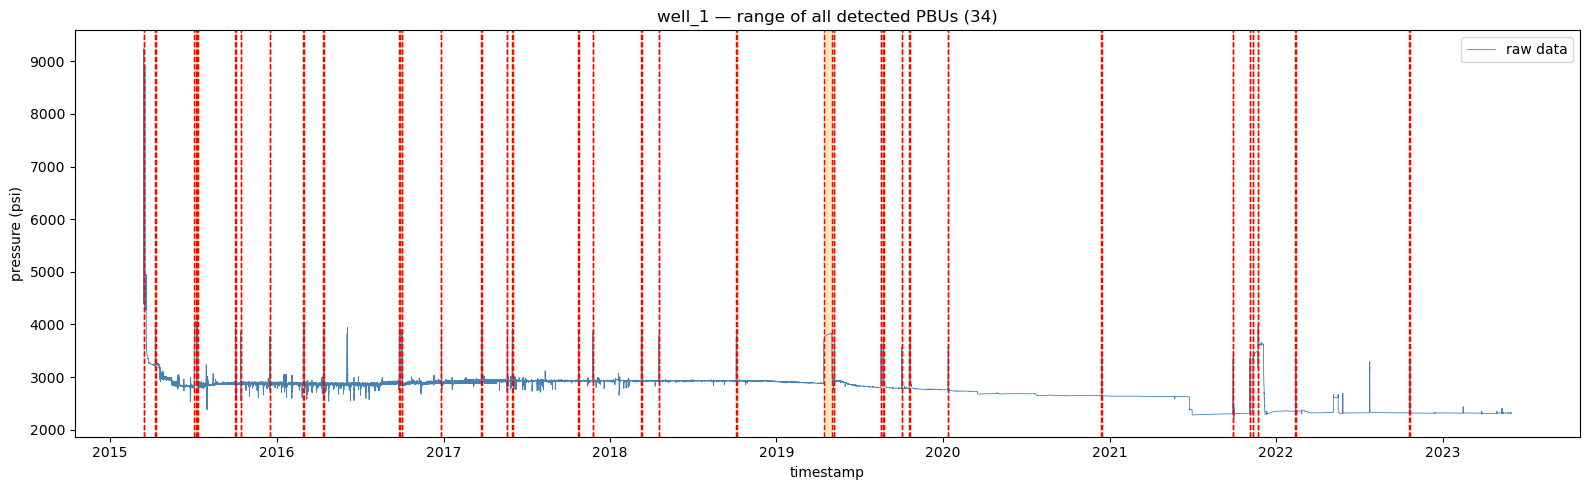

In [27]:
def plot_all_pbus(df, result_df, well_name, max_points=200_000):
    sample_step = max(1, len(df) // max_points)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df.index[::sample_step], df['pressure'].values[::sample_step],
            color='steelblue', lw=0.6, label='raw data')

    for _, row in result_df.iterrows():
        ax.axvspan(row['interval_start'], row['interval_end'], color='orange', alpha=0.25)
        ax.axvline(row['exact_start'], color='red', ls='--', lw=1)
        ax.axvline(row['exact_end'], color='red', ls='--', lw=1)

    ax.set_title(f'{well_name} — range of all detected PBUs ({len(result_df)})')
    ax.set_xlabel('timestamp')
    ax.set_ylabel('pressure (psi)')
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_all_pbus(df, result_df, well_name)

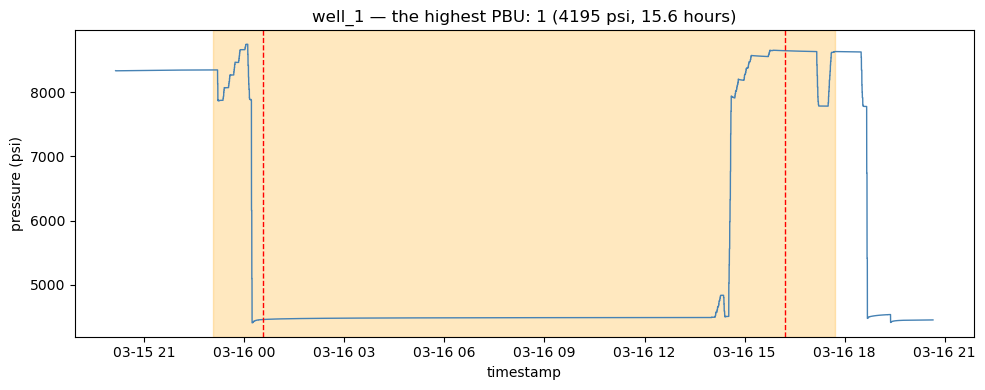

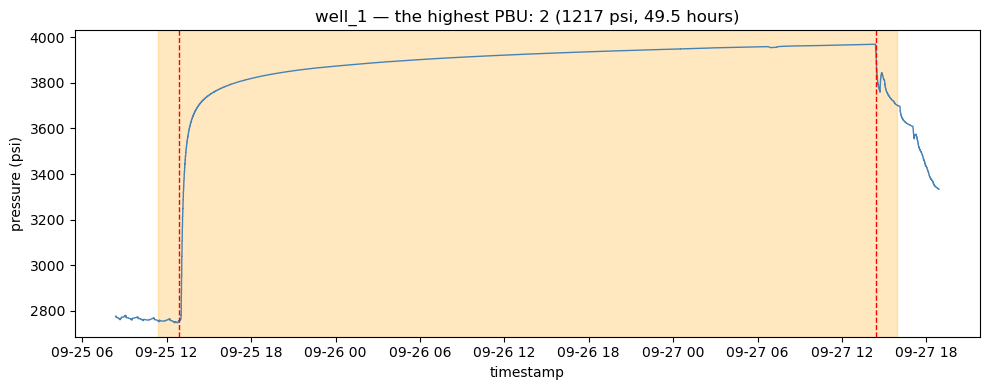

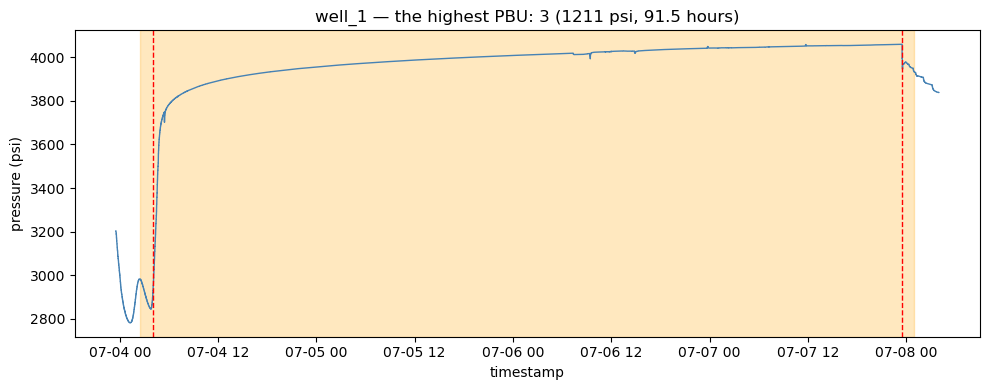

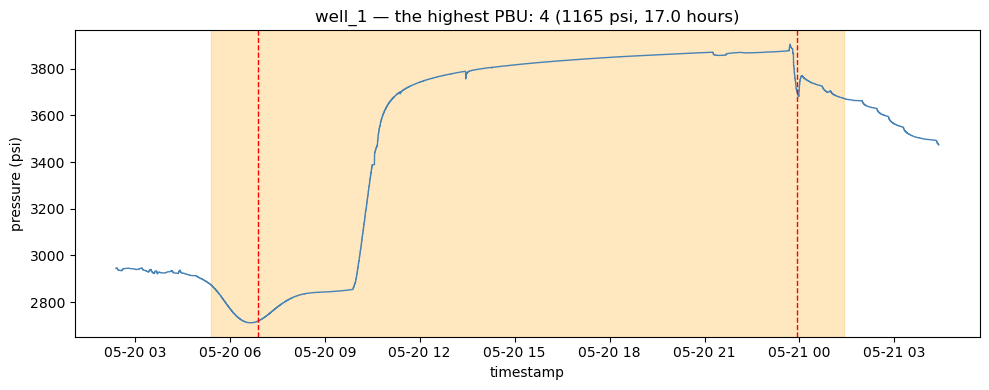

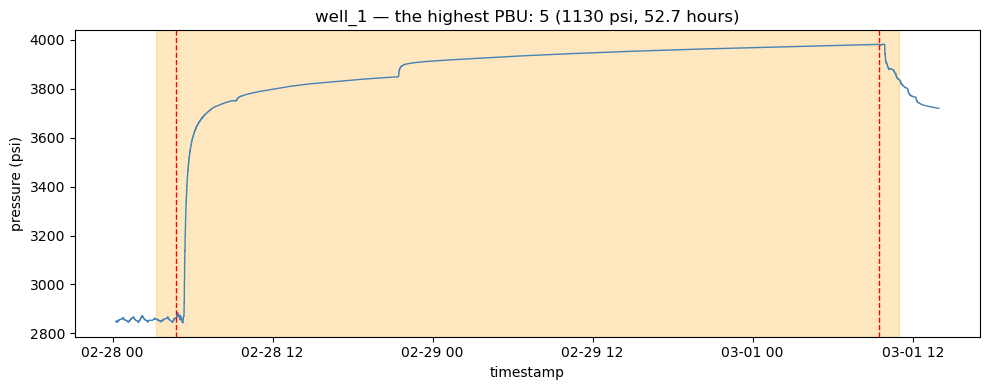

In [28]:
#en yüksek 5 PBU-yu detalli vizuallasdirma
def plot_top_pbus(df, result_df, well_name, top_n=5, criterion='pressure_change_psi', margin_hours=3):
    if result_df.empty:
        print(f'{well_name}: not found PBU.')
        return

    top = result_df.sort_values(criterion, ascending=False).head(top_n)

    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        margin = pd.Timedelta(hours=margin_hours)
        window = df.loc[row['interval_start'] - margin: row['interval_end'] + margin]

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(window.index, window['pressure'].values, color='steelblue', lw=1.0)
        ax.axvspan(row['interval_start'], row['interval_end'], color='orange', alpha=0.25)
        ax.axvline(row['exact_start'], color='red', ls='--', lw=1)
        ax.axvline(row['exact_end'], color='red', ls='--', lw=1)

        ax.set_title(
            f'{well_name} — the highest PBU: {rank} '
            f'({row["pressure_change_psi"]:.0f} psi, {row["duration_hours"]:.1f} hours)'
        )
        ax.set_xlabel('timestamp')
        ax.set_ylabel('pressure (psi)')
        plt.tight_layout()
        plt.show()

plot_top_pbus(df, result_df, well_name, top_n=5)

interval_start    2015-03-15 23:03:25.800000+00:00
exact_start       2015-03-16 00:33:25.800000+00:00
exact_end         2015-03-16 16:12:06.100000+00:00
interval_end      2015-03-16 17:42:06.100000+00:00
Name: 0, dtype: object
count   2,116.00
mean    7,865.21
std     1,710.93
min     4,442.92
25%     7,897.49
50%     8,569.71
75%     8,934.87
max     9,235.96
Name: pressure, dtype: float64


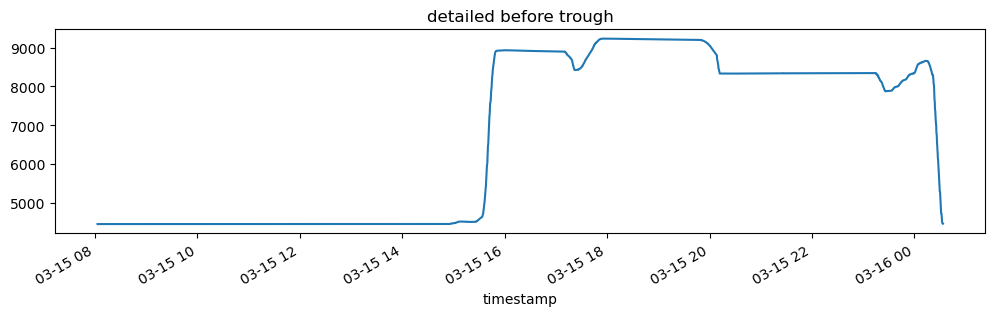

In [29]:
#bu ve asagidaki blok sadece islerin duzgun getdiyinden emin olmaq ucun yazilmisdir
# result_df icindeki 1-ci PBU-nun tam interval_start / exact_start deyerlerini goster
row1 = result_df.sort_values('pressure_change_psi', ascending=False).iloc[0]
print(row1[['interval_start', 'exact_start', 'exact_end', 'interval_end']])

#o araliqdan tam evvelki hisseni zamaniyla birlikde goster
window = smoothed.loc[row1['interval_start'] - pd.Timedelta(hours=16): row1['exact_start']]
window.plot(figsize=(12,3), title='detailed before trough')
print(window.describe())

interval_start    2016-09-25 11:23:13.700000+00:00
exact_start       2016-09-25 12:53:13.700000+00:00
exact_end         2016-09-27 14:23:29.681000+00:00
interval_end      2016-09-27 15:53:29.681000+00:00
Name: 9, dtype: object
count   5,876.00
mean    2,815.26
std        36.19
min     2,751.24
25%     2,776.44
50%     2,824.29
75%     2,849.68
max     2,868.98
Name: pressure, dtype: float64


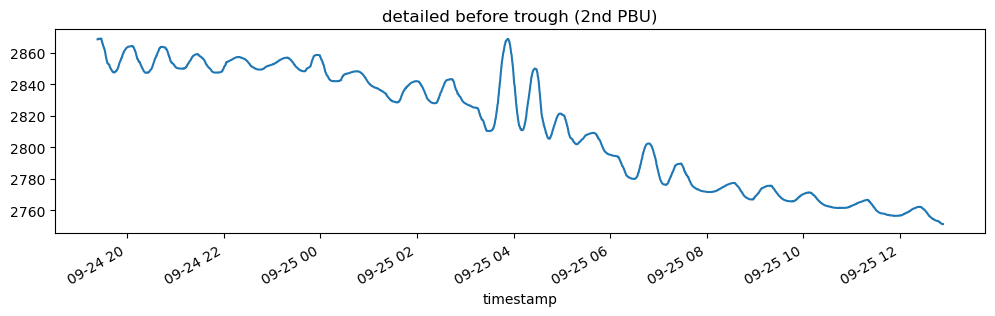

In [30]:
row2 = result_df.sort_values('pressure_change_psi', ascending=False).iloc[1]
print(row2[['interval_start', 'exact_start', 'exact_end', 'interval_end']])

window = smoothed.loc[row2['interval_start'] - pd.Timedelta(hours=16): row2['exact_start']]
window.plot(figsize=(12,3), title='detailed before trough (2nd PBU)')
print(window.describe())

In [31]:
result_df.insert(0, 'well', well_name)
result_df.to_csv(f'{well_name}_pbu_results.csv', index=False)
print(f'saved to {well_name}_pbu_results.csv  ({len(result_df)} PBUs)')
result_df

saved to well_1_pbu_results.csv  (34 PBUs)


,well,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,well_1,2015-03-16 00:33:25.800000+00:00,2015-03-15 23:03:25.800000+00:00,2015-03-16 16:12:06.100000+00:00,2015-03-16 17:42:06.100000+00:00,15.64,"4,194.79"
1,well_1,2015-04-09 14:20:47+00:00,2015-04-09 12:50:47+00:00,2015-04-10 09:58:37.603000+00:00,2015-04-10 11:28:37.603000+00:00,19.63,810.86
2,well_1,2015-07-04 04:01:19.800000+00:00,2015-07-04 02:31:19.800000+00:00,2015-07-07 23:29:58.900000+00:00,2015-07-08 00:59:58.900000+00:00,91.48,"1,211.06"
3,well_1,2015-07-09 18:17:24+00:00,2015-07-09 16:47:24+00:00,2015-07-11 11:15:54.500000+00:00,2015-07-11 12:45:54.500000+00:00,40.98,"1,126.97"
4,well_1,2015-10-02 08:11:20+00:00,2015-10-02 06:41:20+00:00,2015-10-03 06:36:55.336000+00:00,2015-10-03 08:06:55.336000+00:00,22.43,"1,084.45"
5,well_1,2015-10-13 21:54:19.100000+00:00,2015-10-13 20:24:19.100000+00:00,2015-10-14 02:44:20.400000+00:00,2015-10-14 04:14:20.400000+00:00,4.83,996.85
6,well_1,2015-12-16 09:27:29.400000+00:00,2015-12-16 07:57:29.400000+00:00,2015-12-17 04:01:51.300000+00:00,2015-12-17 05:31:51.300000+00:00,18.57,993.63
7,well_1,2016-02-28 04:44:51+00:00,2016-02-28 03:14:51+00:00,2016-03-01 09:27:55.350000+00:00,2016-03-01 10:57:55.350000+00:00,52.72,"1,130.16"
8,well_1,2016-04-11 01:49:21.804000+00:00,2016-04-11 00:19:21.804000+00:00,2016-04-12 21:36:10.304000+00:00,2016-04-12 23:06:10.304000+00:00,43.78,907.98
9,well_1,2016-09-25 12:53:13.700000+00:00,2016-09-25 11:23:13.700000+00:00,2016-09-27 14:23:29.681000+00:00,2016-09-27 15:53:29.681000+00:00,49.50,"1,216.88"
